**In this notebook, I did sentiment analysis on amazon-fine-food review data (https://www.kaggle.com/code/robikscube/sentiment-analysis-python-youtube-tutorial?select=Reviews.csv) using Three different tenchniques:**
1. VADER (Valence Aware Dictionary and sEntiment Reasoner) - Bag of words approach
2. Roberta Pretrained Model from Huggingface (https://huggingface.co/cardiffnlp/twitter-roberta-base-sentiment-latest)
3. Huggingface pipeline

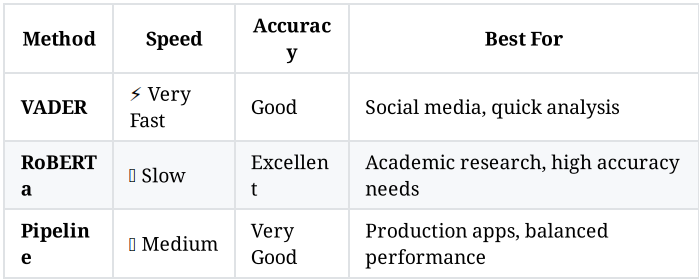

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

plt.style.use('ggplot')
nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [2]:
# Load Amazon Reviews dataset
df = pd.read_csv('Reviews.csv')
df = df.dropna(subset=['Text'])

In [ ]:
# Run VADER sentiment analysis
df['vader'] = df['Text'].apply(sia.polarity_scores)
df['compound'] = df['vader'].apply(lambda d: d['compound'])
df['pos'] = df['vader'].apply(lambda d: d['pos'])
df['neu'] = df['vader'].apply(lambda d: d['neu'])
df['neg'] = df['vader'].apply(lambda d: d['neg'])

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')

In [2]:
import nltk
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('maxent_ne_chunker')
nltk.download('words')
nltk.download('vader_lexicon')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package words to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [5]:
df = pd.read_csv('Reviews.csv')
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [6]:
print(f'Total reviews: {len(df)}')

Total reviews: 568454


In [7]:
print(f'Dataset shape: {df.shape}')

Dataset shape: (568454, 10)


In [8]:
print(f'Columns: {df.columns.tolist()}')

Columns: ['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']


In [9]:
df.describe()

,Id,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time
count,568454.000000,568454.000000,568454.00000,568454.000000,5.684540e+05
mean,284227.500000,1.743817,2.22881,4.183199,1.296257e+09
std,164098.679298,7.636513,8.28974,1.310436,4.804331e+07
min,1.000000,0.000000,0.00000,1.000000,9.393408e+08
25%,142114.250000,0.000000,0.00000,4.000000,1.271290e+09
50%,284227.500000,0.000000,1.00000,5.000000,1.311120e+09
75%,426340.750000,2.000000,2.00000,5.000000,1.332720e+09
max,568454.000000,866.000000,923.00000,5.000000,1.351210e+09


In [11]:
df['Text'].isnull()

0         False
1         False
2         False
3         False
4         False
          ...  
568449    False
568450    False
568451    False
568452    False
568453    False
Name: Text, Length: 568454, dtype: bool

In [12]:
df = df.head(500)
df = df.dropna(subset=['Text'])  #remove rows with missing text

In [13]:
print(f'Working with {len(df)} Reviews')

Working with 500 Reviews


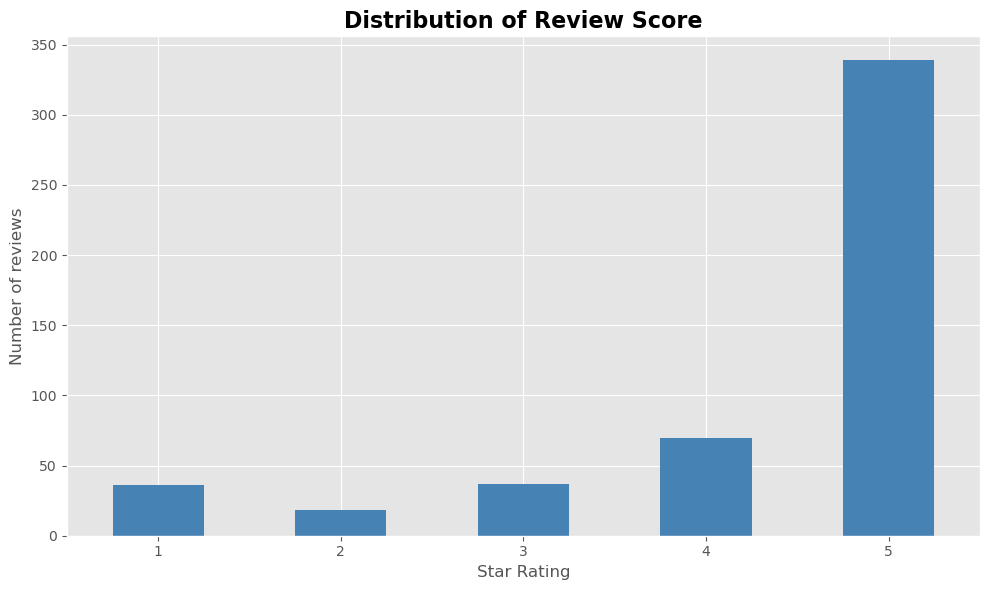

In [15]:
plt.figure(figsize=(10, 6))
score_counts = df['Score'].value_counts().sort_index()
score_counts.plot(kind='bar', color='steelblue')
plt.title('Distribution of Review Score', fontsize=16, fontweight='bold')
plt.xlabel('Star Rating', fontsize=12)
plt.ylabel('Number of reviews', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [16]:
print(f'\nReview Score Statistics')
print(df['Score'].value_counts().sort_index())


Review Score Statistics
Score
1     36
2     18
3     37
4     70
5    339
Name: count, dtype: int64


In [17]:
example_text = df['Text'].iloc[50]
print("Example Review:")
print(f'{example_text}\n')

Example Review:
This oatmeal is not good. Its mushy, soft, I don't like it. Quaker Oats is the way to go.



In [20]:
#Split text into words
tokens = nltk.word_tokenize(example_text)
print(f'Tokens (first 10): {tokens[:10]}')

Tokens (first 10): ['This', 'oatmeal', 'is', 'not', 'good', '.', 'Its', 'mushy', ',', 'soft']


In [24]:
# Part-Of-Speech (POS) Tagging
pos = nltk.pos_tag(tokens)
print(f'POS Tags (first 10): \n{pos[:10]}')

POS Tags (first 10): 
[('This', 'DT'), ('oatmeal', 'NN'), ('is', 'VBZ'), ('not', 'RB'), ('good', 'JJ'), ('.', '.'), ('Its', 'PRP$'), ('mushy', 'NN'), (',', ','), ('soft', 'JJ')]


In [26]:
# Named entity recognition
entities = nltk.chunk.ne_chunk(pos)
print('Named Entities:')
print(entities)

Named Entities:
(S
  This/DT
  oatmeal/NN
  is/VBZ
  not/RB
  good/JJ
  ./.
  Its/PRP$
  mushy/NN
  ,/,
  soft/JJ
  ,/,
  I/PRP
  do/VBP
  n't/RB
  like/VB
  it/PRP
  ./.
  (ORGANIZATION Quaker/NNP Oats/NNPS)
  is/VBZ
  the/DT
  way/NN
  to/TO
  go/VB
  ./.)


### Vader Snetiment Analyziz

- Vader is a rule based sentiment analyzer optimized for social media text. It is fast and does not require any trainig.

In [27]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from tqdm.notebook import tqdm

In [28]:
sia = SentimentIntensityAnalyzer()

### Test on Single Example

In [29]:
print('Vader Sentiment Analyziz Examples:\n')

test_sentences = [
    'I am so happy with this product',
    'This is the worst thing I have ever bought',
    'It is okay, nothing special.'
]

for sentence in test_sentences:
    scores = sia.polarity_scores(sentence)
    print(f'Text: {sentence}')
    print(f'Scores: {scores}')
    print(f"Overall: {'Positive'if scores['compound'] >= 0.05 else 'Negative' if scores['compound'] <= -0.05 else 'Neutral'}\n")

Vader Sentiment Analyziz Examples:

Text: I am so happy with this product
Scores: {'neg': 0.0, 'neu': 0.556, 'pos': 0.444, 'compound': 0.6115}
Overall: Positive

Text: This is the worst thing I have ever bought
Scores: {'neg': 0.369, 'neu': 0.631, 'pos': 0.0, 'compound': -0.6249}
Overall: Negative

Text: It is okay, nothing special.
Scores: {'neg': 0.315, 'neu': 0.419, 'pos': 0.265, 'compound': -0.092}
Overall: Negative



### Applying Vader to all reviews

In [34]:
print('Analying Sentiment for all reviews:')

df['vader_scores'] = df['Text'].apply(lambda x: sia.polarity_scores(str(x)))
df['vader_compound'] = df['vader_scores'].apply(lambda d: d['compound'])
df['vader_pos'] = df['vader_scores'].apply(lambda d: d['pos'])
df['vader_neu'] = df['vader_scores'].apply(lambda d: d['neu'])
df['vader_neg'] = df['vader_scores'].apply(lambda d: d['neg'])

print('\nSentiment Analyziz results:')
print(df[['Text', 'Score', 'vader_scores', 'vader_pos', 'vader_neu', 'vader_neg', 'vader_compound']].head(10))

Analying Sentiment for all reviews:

Sentiment Analyziz results:
                                                Text  Score  \
0  I have bought several of the Vitality canned d...      5   
1  Product arrived labeled as Jumbo Salted Peanut...      1   
2  This is a confection that has been around a fe...      4   
3  If you are looking for the secret ingredient i...      2   
4  Great taffy at a great price.  There was a wid...      5   
5  I got a wild hair for taffy and ordered this f...      4   
6  This saltwater taffy had great flavors and was...      5   
7  This taffy is so good.  It is very soft and ch...      5   
8  Right now I'm mostly just sprouting this so my...      5   
9  This is a very healthy dog food. Good for thei...      5   

                                        vader_scores  vader_pos  vader_neu  \
0  {'neg': 0.0, 'neu': 0.695, 'pos': 0.305, 'comp...      0.305      0.695   
1  {'neg': 0.138, 'neu': 0.862, 'pos': 0.0, 'comp...      0.000      0.862   
2  {'ne

## Visualize Vader Result

### Compaer Vader compound scores vs Amazon star ratings

C:\Users\USER\AppData\Local\Temp\ipykernel_38956\96161358.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df, x='Score', y='vader_compound', palette='viridis', errorbar='sd')


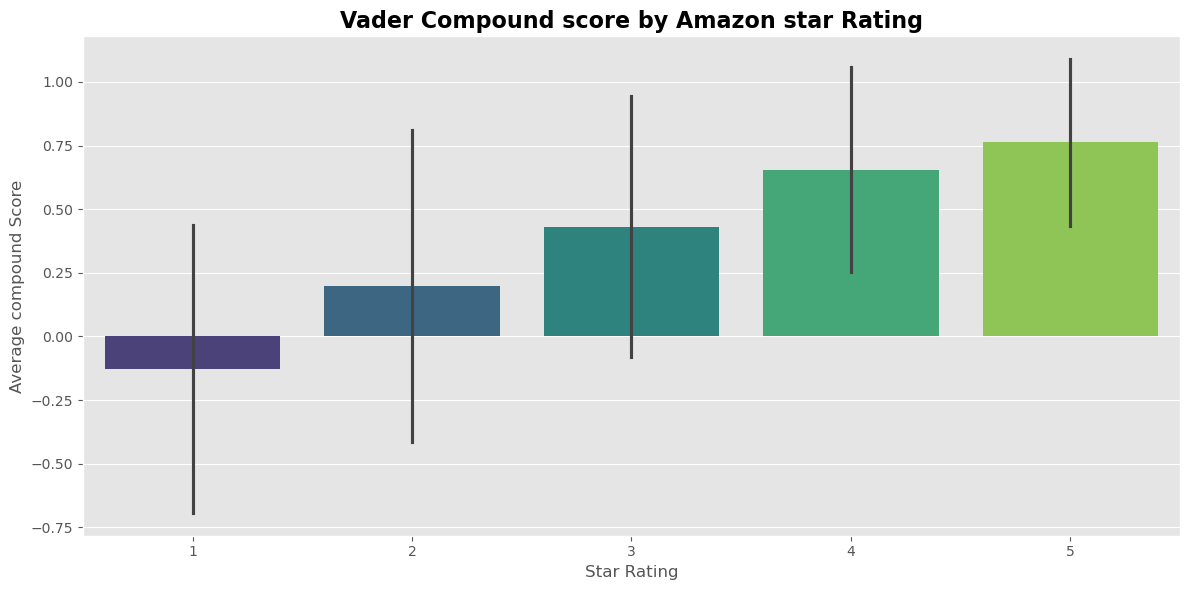

In [35]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=df, x='Score', y='vader_compound', palette='viridis', errorbar='sd')
ax.set_title('Vader Compound score by Amazon star Rating', fontsize=16, fontweight='bold')
ax.set_xlabel('Star Rating', fontsize=12)
ax.set_ylabel('Average compound Score', fontsize=12)
plt.tight_layout()
plt.show()

### Correlation Between star Rating and Sentiment:

In [39]:
correlation = df['Score'].corr(df['vader_compound'])
print(f'Correlation between star rating and vader compound: {correlation:.3f}')

Correlation between star rating and vader compound: 0.536


### Roberta Sentiment Analyziz (More Accurate)

- Roberta is a transformer model trained specifically for sentiment Analysis. More Accurate but slower than vader.

In [42]:
pip install transformers torch scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [45]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

### Load Pre-Trained RoBERTa model for sentiment analyziz

In [53]:
MODEL = f"cardiffnlp/twitter-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)

config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

C:\Users\USER\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\USER\.cache\huggingface\hub\models--cardiffnlp--twitter-roberta-base-sentiment. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

In [58]:
from scipy.special import softmax
import torch

In [59]:
def get_roberta_sentiment(text):
    # analyse sentiment with roberta model
    # Returns scores for negative, neutral and positive sentiment

    try:
        # Truncate long text to avoid errors
        encoded = tokenizer(text, return_tensors='pt', truncation=True, max_length=512)

        #get model predictions
        with torch.no_grad():
            output = model(**encoded)

        # Convert to probabilities
        scores = output.logits[0].numpy()
        scores = softmax(scores)

        # Return as dictionary
        return {
            'roberta_neg': float(scores[0]),
            'roberta_neu': float(scores[1]),
            'roberta_pos': float(scores[2])
        }

    except Exception as e:
        print(f'Error processing text: {e}')
        return {'roberta_neg': 0, 'roberta_neu': 0, 'roberta_pos': 0}
        

### Test on single example

In [60]:
example = df['Text'].iloc[0]
print(f'Example Review: \n{example}')

Example Review: 
I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labrador is finicky and she appreciates this product better than  most.


In [61]:
result = get_roberta_sentiment(example)
print(f'RoBERTa Sentiment Score: {result}')

RoBERTa Sentiment Score: {'roberta_neg': 0.009624222293496132, 'roberta_neu': 0.04998035356402397, 'roberta_pos': 0.9403953552246094}


### Applying RoBERTa on all reviews with error handling

In [70]:
print('Analyze Sentiment with RoBERTa:')

roberta_results = []

for text in tqdm(df['Text'], total=len(df)):
    result = get_roberta_sentiment(str(text))
    roberta_results.append(result)

Analyze Sentiment with RoBERTa:


  0%|          | 0/500 [00:00<?, ?it/s]

### Add results to DataFrame

In [71]:
df['roberta_neg'] = [r['roberta_neg'] for r in roberta_results]
df['roberta_neu'] = [r['roberta_neu'] for r in roberta_results]
df['roberta_pos'] = [r['roberta_pos'] for r in roberta_results]

print('RoBERTa Analysis complete:')
print(df[['Text', 'Score', 'roberta_neg', 'roberta_neu', 'roberta_pos']].head(10))

RoBERTa Analysis complete:
                                                Text  Score  roberta_neg  \
0  I have bought several of the Vitality canned d...      5     0.009624   
1  Product arrived labeled as Jumbo Salted Peanut...      1     0.508986   
2  This is a confection that has been around a fe...      4     0.003229   
3  If you are looking for the secret ingredient i...      2     0.002295   
4  Great taffy at a great price.  There was a wid...      5     0.001635   
5  I got a wild hair for taffy and ordered this f...      4     0.006130   
6  This saltwater taffy had great flavors and was...      5     0.001305   
7  This taffy is so good.  It is very soft and ch...      5     0.002029   
8  Right now I'm mostly just sprouting this so my...      5     0.003874   
9  This is a very healthy dog food. Good for thei...      5     0.003103   

   roberta_neu  roberta_pos  
0     0.049980     0.940395  
1     0.452414     0.038600  
2     0.098067     0.898704  
3     0.090219  

### Compare positive and negative scores by star rating

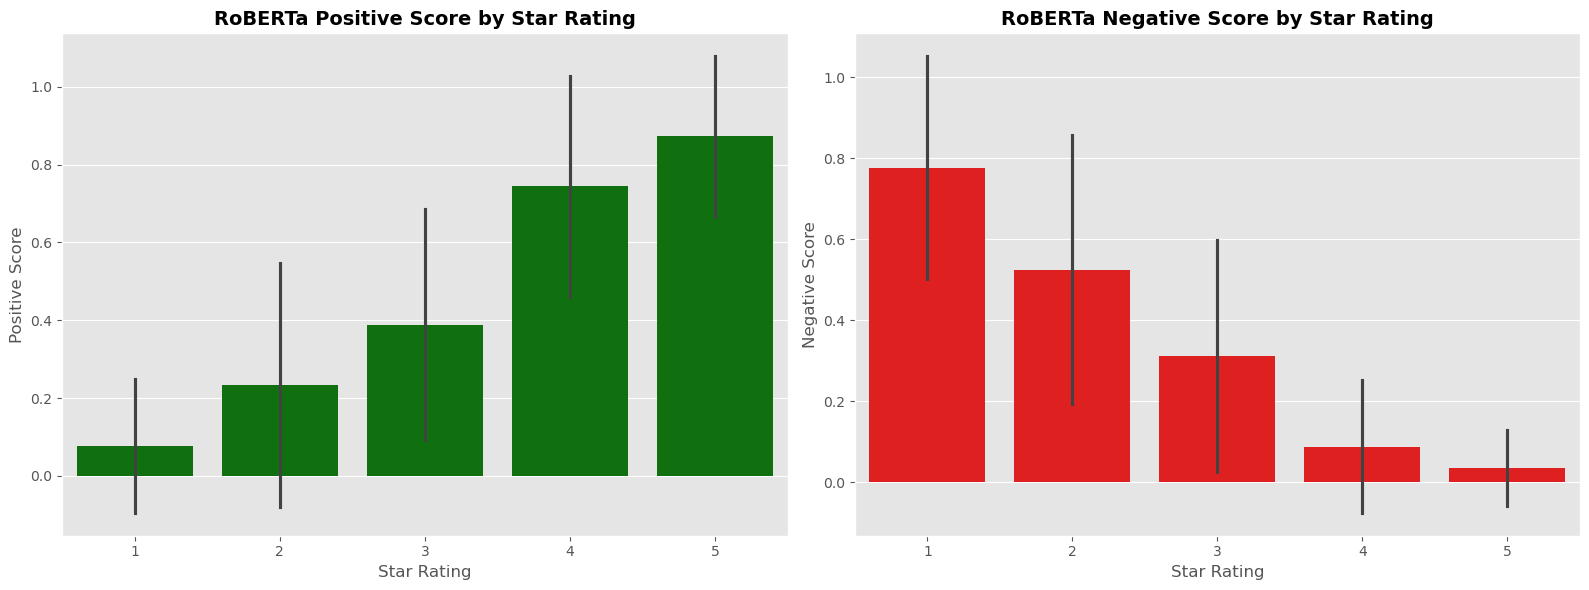

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Positive Sentiment
sns.barplot(data=df, x='Score', y='roberta_pos', ax=axes[0], color='green', errorbar='sd')
axes[0].set_title('RoBERTa Positive Score by Star Rating', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Positive Score')

# Negative Sentiment
sns.barplot(data=df, x='Score', y='roberta_neg', ax=axes[1], color='red', errorbar='sd')
axes[1].set_title('RoBERTa Negative Score by Star Rating', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Star Rating')
axes[1].set_ylabel('Negative Score')

plt.tight_layout()
plt.show()

## Using Transformers Pipeline (Easiest Method)

- The simplest way to use transformer model - just one line

In [73]:
from transformers import pipeline

### Create Sentiment analysis pipeline

In [84]:
pip install tf-keras

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [91]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"  # Force TF to use Keras 2

from transformers import pipeline
# Force the pipeline to use PyTorch
sentiment_pipeline = pipeline('sentiment-analysis', model = 'distilbert-base-uncased-finetuned-sst-2-english', framework='pt') #Explicitly use PyTorch

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Device set to use cpu


In [104]:
# Test it works
result = sentiment_pipeline('I love you')
print(result)

[{'label': 'POSITIVE', 'score': 0.9998656511306763}]


In [92]:
### Test on example
for i in range(5):
    text = df['Text'].iloc[i]
    result = sentiment_pipeline(text[:512])[0]  # Truncate to 512 chars

In [93]:
print(f"Review: {text[:100]}...")
print(f"Prediction: {result['label']} (confidence: {result['score']:.3f})")
print(f"Actual Star Rating: {df['Score'].iloc[i]}\n")

Review: Great taffy at a great price.  There was a wide assortment of yummy taffy.  Delivery was very quick....
Prediction: POSITIVE (confidence: 0.999)
Actual Star Rating: 5



### Add pipeline predictions to dataframe

In [105]:
pipeline_result = []

print('Running Pipeline Sentiment Analysis:')


for text in tqdm(df['Text'], total=len(df)):
    try:
        result = sentiment_pipeline(str(text)[:512])[0]
        pipeline_result.append({'pipeline_label': result['label'], 'pipeline_score': result['score']})


    except:
        pipeline_result.append({'pipeline_label': 'Neutral', 'pipeline_score': 0.5})
        

Running Pipeline Sentiment Analysis:


  0%|          | 0/500 [00:00<?, ?it/s]

In [106]:
df['pipeline_label'] = [r['pipeline_label'] for r in pipeline_result]
df['pipeline_score'] = [r['pipeline_score'] for r in pipeline_result]

In [110]:
sentiment_pipeline('I drink water')

[{'label': 'POSITIVE', 'score': 0.9518932700157166}]

In [111]:
sentiment_pipeline('He is not great but good')

[{'label': 'POSITIVE', 'score': 0.9993051290512085}]

### Create comparison visualization

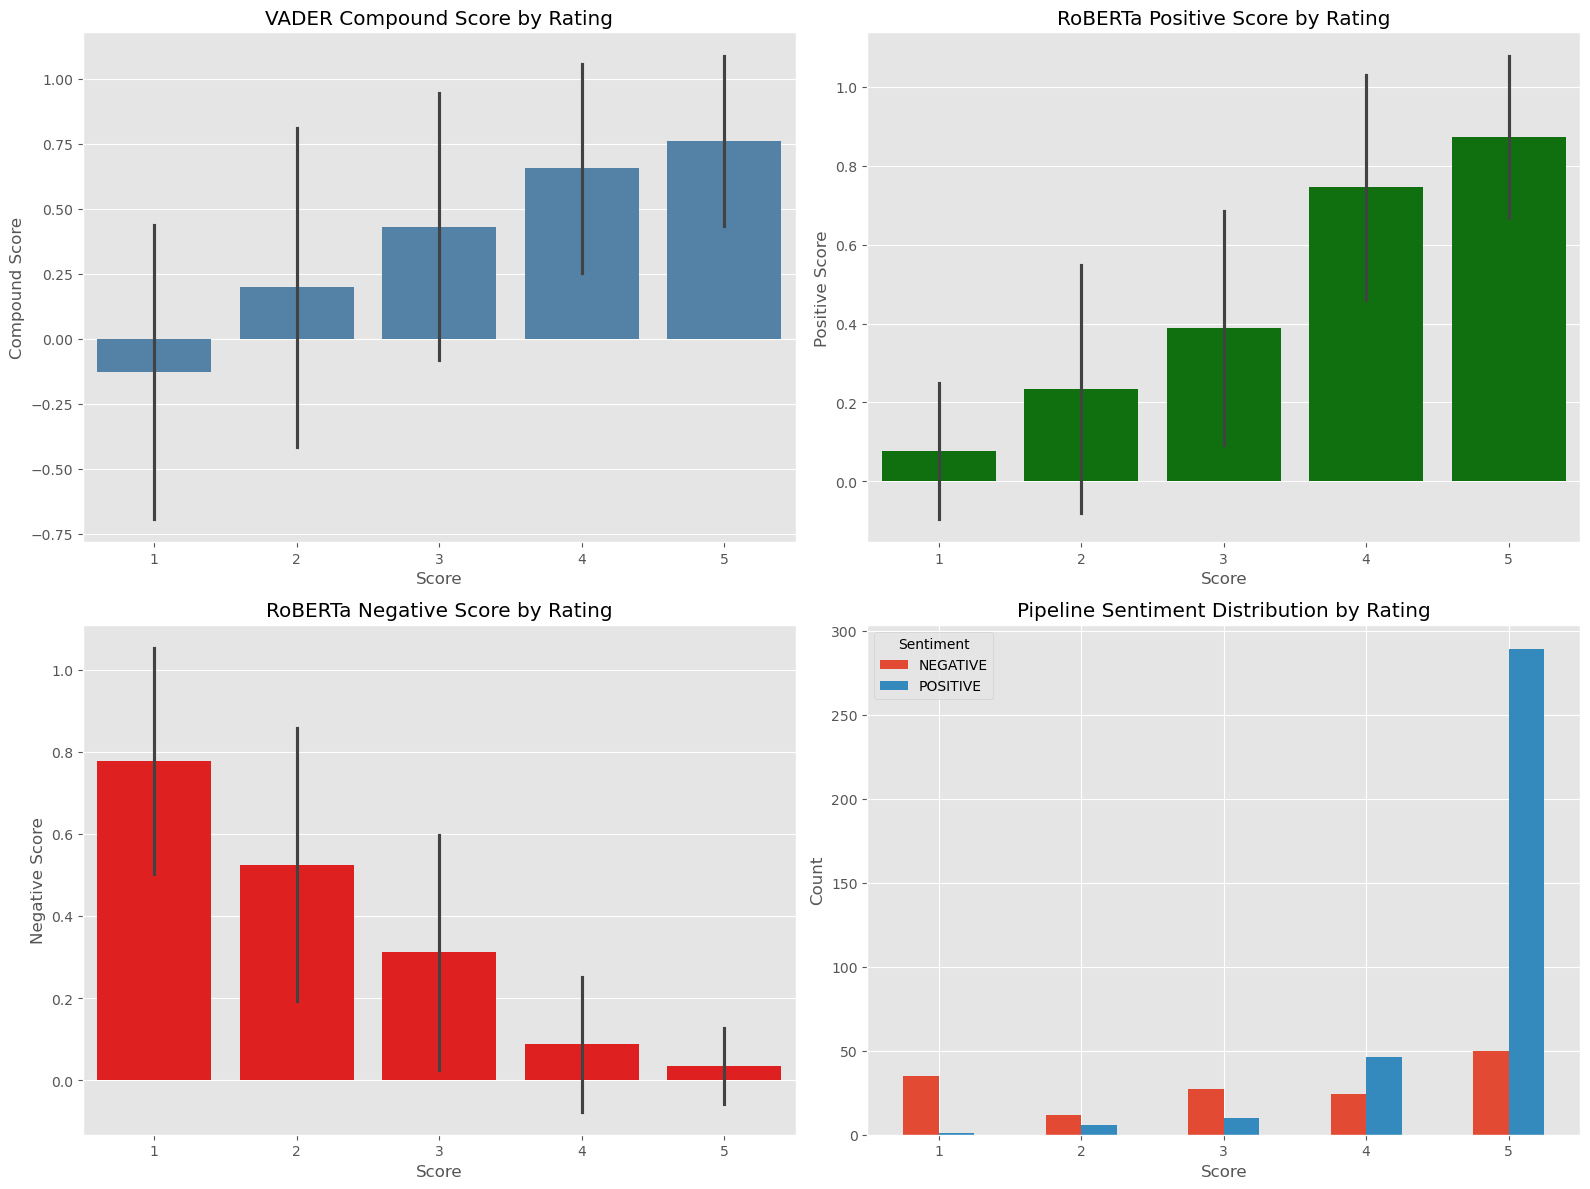

In [113]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Vader Compound
sns.barplot(data=df, x='Score', y='vader_compound', ax=axes[0, 0], color='steelblue', errorbar='sd')
axes[0, 0].set_title('VADER Compound Score by Rating')
axes[0, 0].set_ylabel('Compound Score')

# RoBERTa Positive
sns.barplot(data=df, x='Score', y='roberta_pos', ax=axes[0, 1],
color='green', errorbar='sd')
axes[0, 1].set_title('RoBERTa Positive Score by Rating')
axes[0, 1].set_ylabel('Positive Score')

#RoBERTa Negative
sns.barplot(data=df, x='Score', y='roberta_neg', ax=axes[1, 0],
color='red', errorbar='sd')
axes[1, 0].set_title('RoBERTa Negative Score by Rating')
axes[1, 0].set_ylabel('Negative Score')

# Pipeline Score Distribution
sentiment_by_rating = df.groupby(['Score', 'pipeline_label']).size().unstack(fill_value=0)
sentiment_by_rating.plot(kind='bar', ax=axes[1, 1], stacked=False)
axes[1, 1].set_title('Pipeline Sentiment Distribution by Rating')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=0)
axes[1, 1].legend(title='Sentiment')
plt.tight_layout()
plt.show()

## Save complete results to CSV

In [114]:
output_file = 'sentiment_analysis_results.csv'
df.to_csv(output_file, index=False)
print(f"Results saved to {output_file}")

Results saved to sentiment_analysis_results.csv


### Display final summary

In [115]:
print("\n" + "="*60)
print("SENTIMENT ANALYSIS SUMMARY")
print("="*60)
print(f"Total reviews analyzed: {len(df)}")
print(f"\nAverage VADER compound score: {df['vader_compound'].mean():.3f}")
print(f"Average RoBERTa positive score: {df['roberta_pos'].mean():.3f}")
print(f"Average RoBERTa negative score: {df['roberta_neg'].mean():.3f}")
print(f"\nPipeline predictions:")
print(df['pipeline_label'].value_counts())
print("="*60)


SENTIMENT ANALYSIS SUMMARY
Total reviews analyzed: 500

Average VADER compound score: 0.639
Average RoBERTa positive score: 0.739
Average RoBERTa negative score: 0.134

Pipeline predictions:
pipeline_label
POSITIVE    352
NEGATIVE    148
Name: count, dtype: int64
